<a href="https://colab.research.google.com/github/dlhegend/-TS_Academy_Capstone_Project/blob/restore-main/notebooks/Ugochukwu_Kiloprice_TimeSeries_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import warnings
warnings.filterwarnings('ignore')

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("/content/NGX_ASI_Index_Price_Data.csv")

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   137 non-null    object 
 1   avr_monthly_kiloprice  137 non-null    float64
dtypes: float64(1), object(1)
memory usage: 2.3+ KB


In [21]:
# converting date to datetime and to set it as the index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 137 entries, 2012-01-01 to 2023-05-01
Data columns (total 1 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   avr_monthly_kiloprice  137 non-null    float64
dtypes: float64(1)
memory usage: 2.1 KB


In [23]:
df.describe()

,avr_monthly_kiloprice
count,137.000000
mean,34.301241
std,8.428547
min,20.520000
25%,27.430000
50%,33.350000
75%,39.270000
max,55.080000


In [24]:
df.head()

,avr_monthly_kiloprice
date,
2012-01-01,20.80
2012-02-01,20.52
2012-03-01,20.92
2012-04-01,21.27
2012-05-01,22.41


In [25]:
df.tail()

,avr_monthly_kiloprice
date,
2023-01-01,52.25
2023-02-01,54.43
2023-03-01,55.08
2023-04-01,52.20
2023-05-01,52.34


In [26]:
# checking for null values
df.isna().sum()

,0
avr_monthly_kiloprice,0


In [27]:
# checking for dupliactes
df.duplicated().sum()

np.int64(1)

PLOT THE SERIES TO SEE TREND AND SEASONALITY

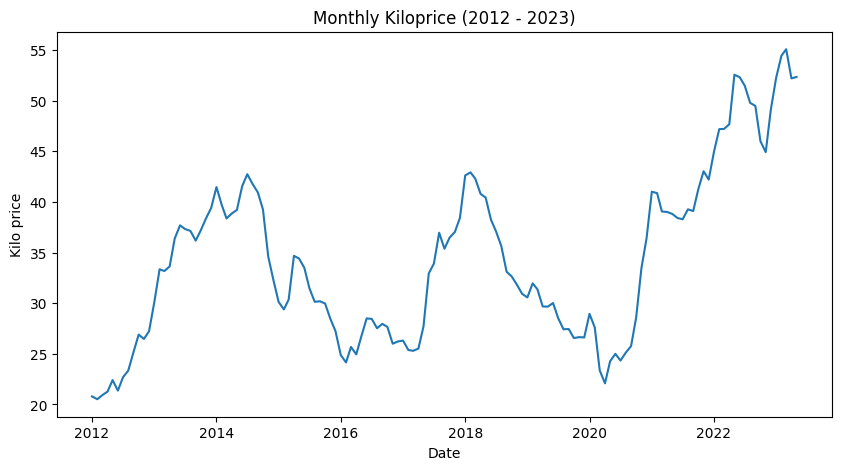

In [28]:
# What is the overall trend of price over time?
plt.figure(figsize=(10,5))
ax = sns.lineplot(data=df, x=df.index, y='avr_monthly_kiloprice')
ax.set(title="Monthly Kiloprice (2012 - 2023)", xlabel="Date", ylabel="Kilo price")
plt.show()

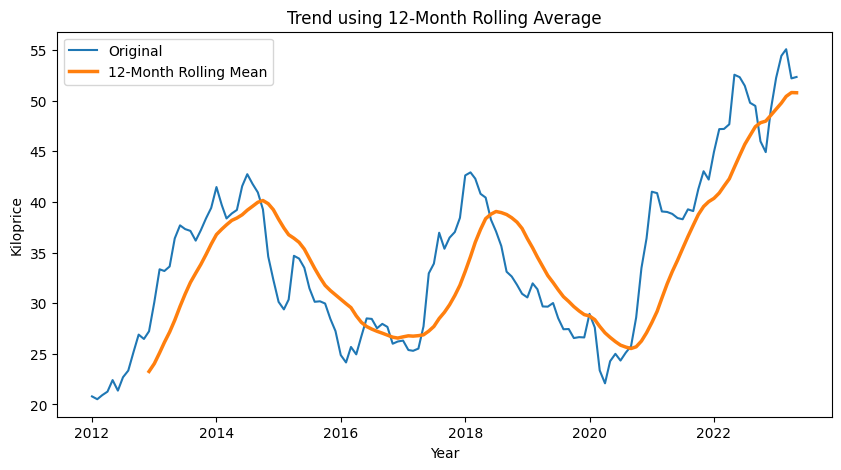

In [29]:
df['rolling_mean_12'] = df['avr_monthly_kiloprice'].rolling(window=12).mean() # didn't add the center attribute to avoid the legend trend line overlapping the actual trend line
plt.figure(figsize=(10,5))
ax = sns.lineplot(data=df, x='date', y='avr_monthly_kiloprice', label='Original')
sns.lineplot(data=df, x='date', y='rolling_mean_12', label='12-Month Rolling Mean', linewidth=2.5) # the legend trend line
ax.set(title="Trend using 12-Month Rolling Average", xlabel="Year", ylabel="Kiloprice")
plt.show()

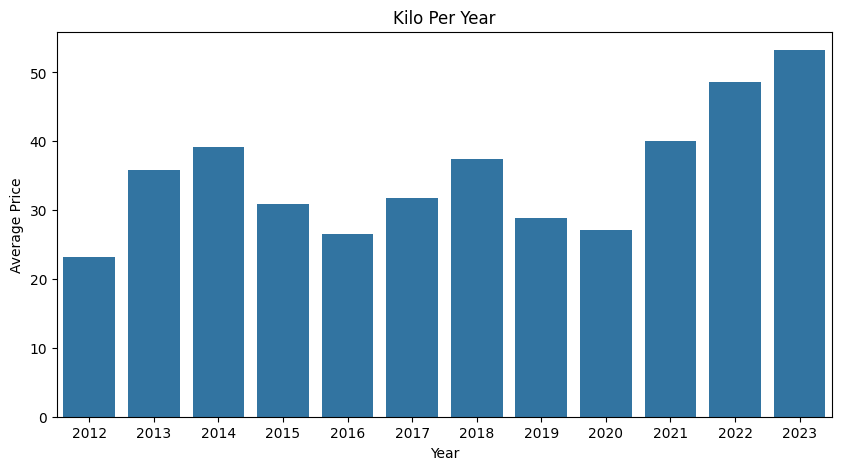

In [30]:
# How has the kiloprice changed from year to year?
df['year'] = df.index.year
plt.figure(figsize=(10,5))
ax = sns.barplot(data=df, x='year', y='avr_monthly_kiloprice', errorbar=None) # errorbar removes the wick
ax.set(title = "Kilo Per Year", xlabel = "Year", ylabel = "Average Price")
plt.show()

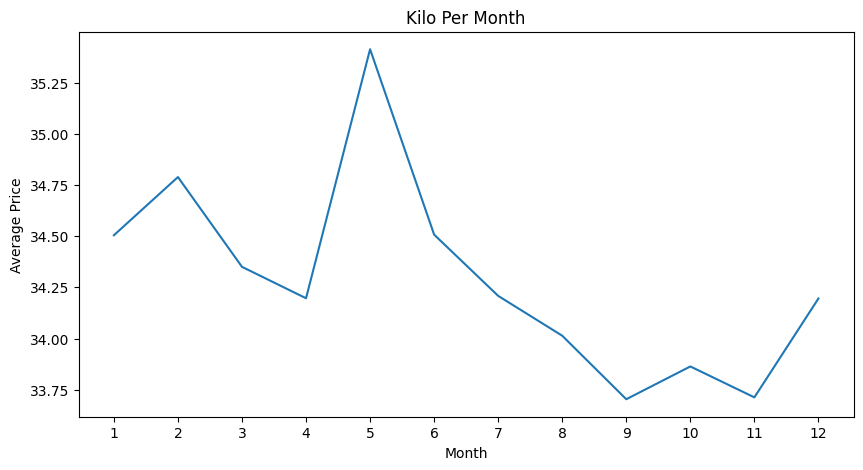

In [31]:
# Do certain months consistently have higher or lower prices?
df['month'] = df.index.month
plt.figure(figsize=(10,5))
ax = sns.lineplot(data=df, x='month', y='avr_monthly_kiloprice', errorbar=None)
ax.set(title="Kilo Per Month", xlabel="Month", ylabel="Average Price")
ax.set_xticks(range(1,13)) # to show all 12 months
plt.show()

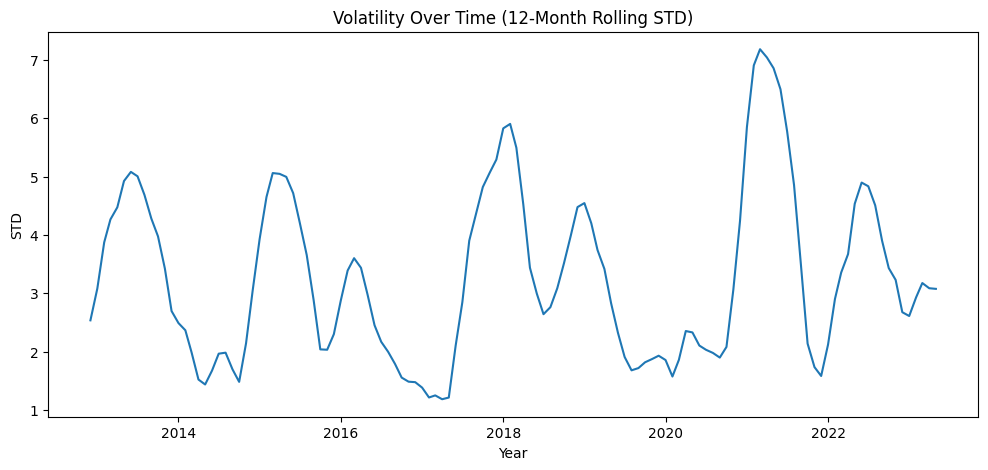

In [32]:
# Price volatility over time
df['rolling_std_12'] = df['avr_monthly_kiloprice'].rolling(window=12).std()
plt.figure(figsize=(12,5))
ax = sns.lineplot(data=df, x='date', y='rolling_std_12')
ax.set(title="Volatility Over Time (12-Month Rolling STD)", xlabel="Year", ylabel="STD")
plt.show()



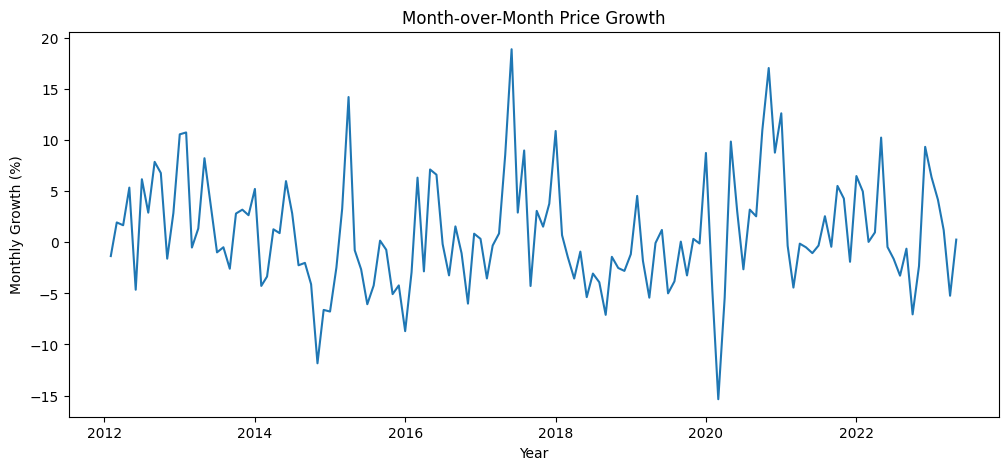

In [33]:
# Line plot for Month-to-month change in price
df['MoM_change'] = df['avr_monthly_kiloprice'].pct_change(periods=1) * 100 # periods=1, compares the current monthly price with the previous month
plt.figure(figsize=(12,5))
ax = sns.lineplot(data=df, x='date', y='MoM_change')
ax.set(title="Month-over-Month Price Growth", xlabel="Year", ylabel="Monthly Growth (%)")
plt.show()

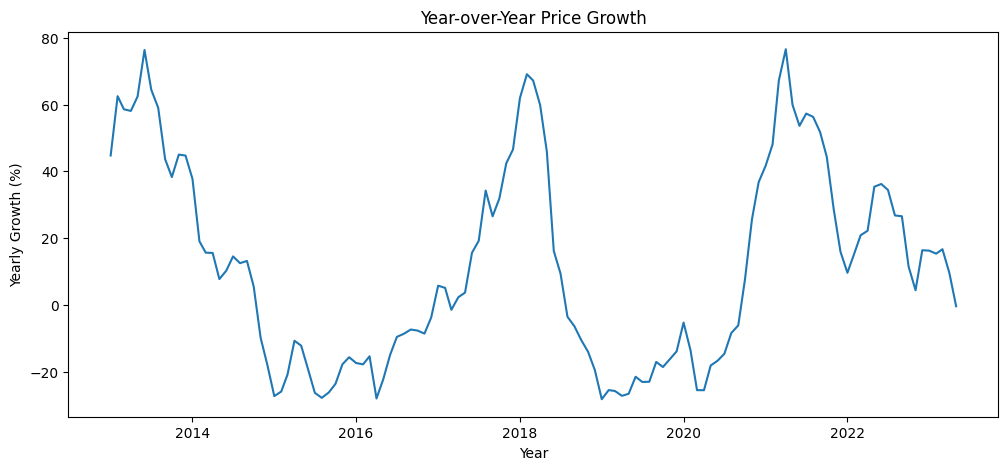

In [34]:
# Year to year change in price
df['YoY_change'] = df['avr_monthly_kiloprice'].pct_change(periods=12) * 100 # periods=12, compares the current yearly price with the previous years price
plt.figure(figsize=(12,5))
ax = sns.lineplot(data=df, x='date', y='YoY_change')
ax.set(title="Year-over-Year Price Growth", xlabel="Year", ylabel="Yearly Growth (%)")
plt.show()

In [35]:
# How much has the average monthly kiloprice increased from 2012 to 2023?
start_price = df['avr_monthly_kiloprice'].iloc[0]
last_price = df['avr_monthly_kiloprice'].iloc[-1]

growth = ((last_price - start_price) / start_price) * 100
print(f"Price increased by {growth:.2f}% from 2012 - 2023")

Price increased by 151.63% from 2012 - 2023


In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

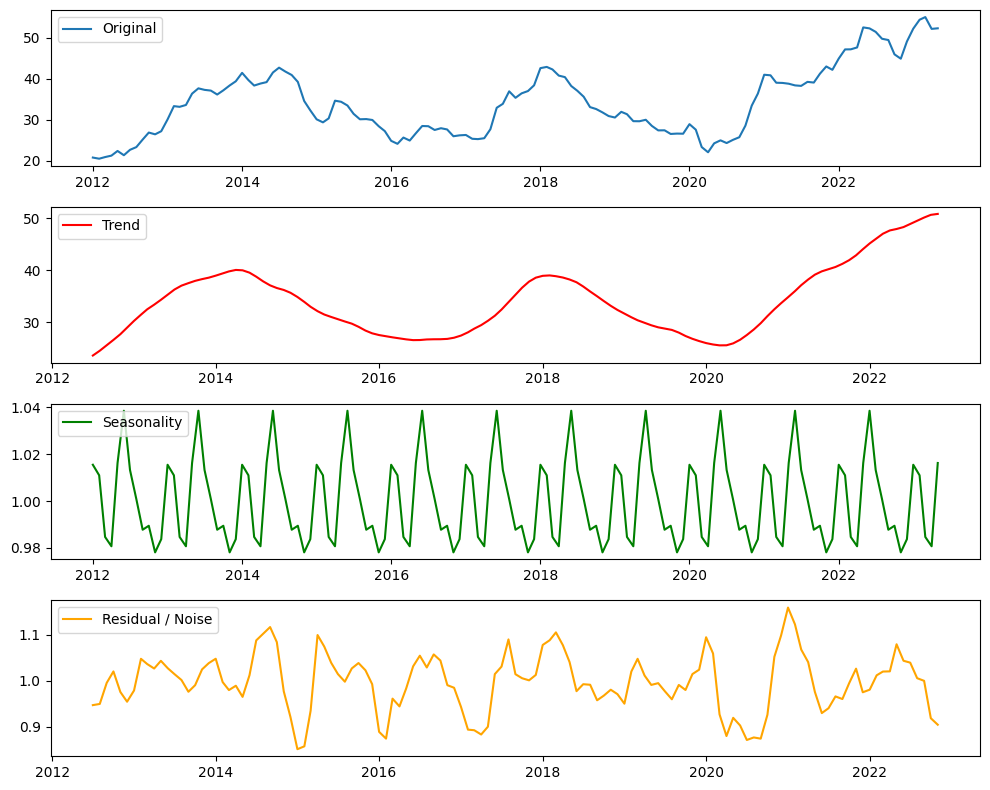

In [37]:
decomposition = seasonal_decompose(df['avr_monthly_kiloprice'], model='multiplicative', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(10,8))

plt.subplot(4,1,1)
plt.plot(df['avr_monthly_kiloprice'], label='Original')
plt.legend(loc='upper left')

plt.subplot(4,1,2)
plt.plot(trend, label='Trend', color='red')
plt.legend(loc='upper left')

plt.subplot(4,1,3)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')

plt.subplot(4,1,4)
plt.plot(residual, label='Residual / Noise', color='orange')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

TEST FOR STATIONARITY

In [38]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['avr_monthly_kiloprice'])

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
  print('This series is likely stationery')
else:
  print('This series is likely non-stationery')


ADF Statistic: -1.6879689803233129
p-value: 0.4373216371351407
This series is likely non-stationery


DUE TO SEASONALITY OF THE DATA, I AM RUNNING SEASONAL DIFFERENCING FIRST

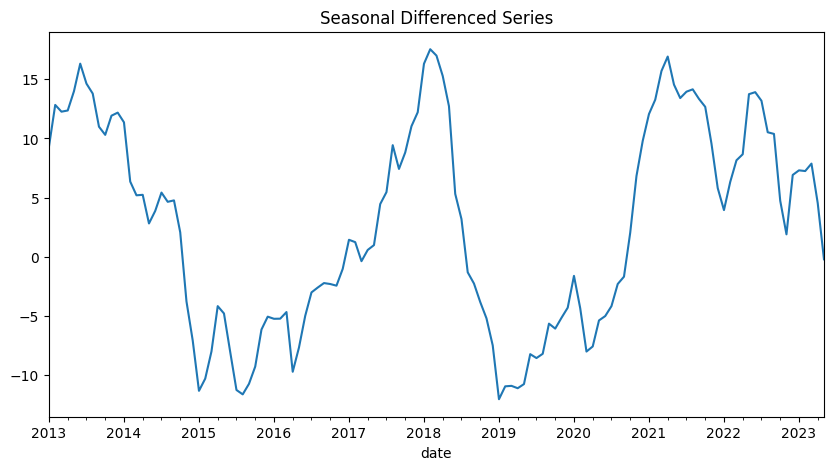

In [39]:
df['Seasonal_Diff'] = df['avr_monthly_kiloprice'] - df['avr_monthly_kiloprice'].shift(12)
df_seasonal = df['Seasonal_Diff'].dropna()

df_seasonal.plot(title='Seasonal Differenced Series', figsize=(10,5))
plt.show()

In [40]:
result = adfuller(df_seasonal)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] < 0.05:
  print('This series is likely stationery')
else:
  print('This series is likely non-stationery')

ADF Statistic: -2.2818008462141313
p-value: 0.17790475474067885
This series is likely non-stationery


SERIES IS STILL NON-STATIONERY SO I WILL RUN FIRST DIFFERENCING ON THE SEASONAL-DIFFERENCED SERIES

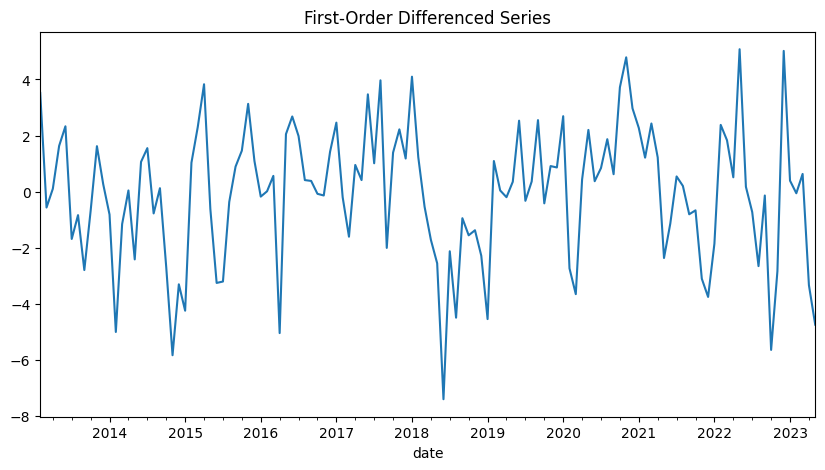

In [41]:
df['Diff_1'] = df['Seasonal_Diff'].diff()
df_diff = df['Diff_1'].dropna()

df_diff.plot(title='First-Order Differenced Series', figsize=(10,5))
plt.show()

In [42]:
res_diff = adfuller(df_diff)

print(f'ADF Statistic: {res_diff[0]}')
print(f'p-value: {res_diff[1]}')

if res_diff[1] < 0.05:
  print('This series is likely stationery')
else:
  print('This series is likely non-stationery')

ADF Statistic: -3.2975378175876107
p-value: 0.01498889349403068
This series is likely stationery


dATA IS NOW STATIIONERY, WE MOVE TO GET THE ORDER PARAMETERS USING ACF & PACF FOR p, P, q, and Q, WE ALREADY KNOW D AND d to be = 1.

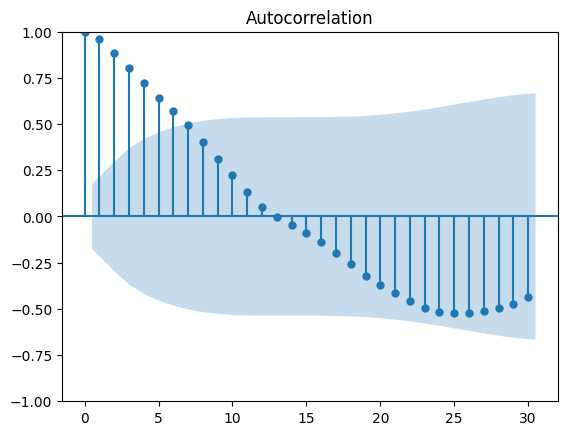

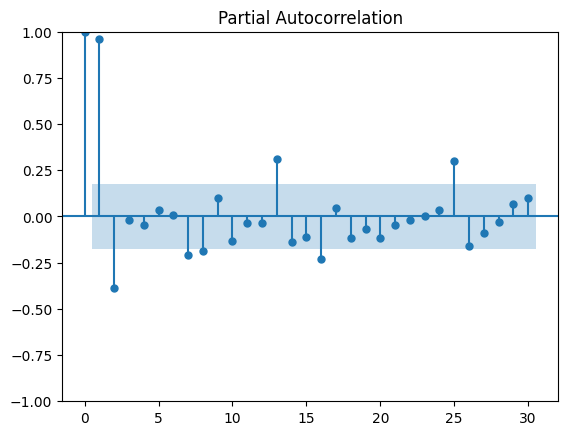

In [65]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_seasonal, lags=30)
plt.show()

plot_pacf(df_seasonal, lags=30)
plt.show()

SPLITTING OUR DATASET INTO TRAIN SET(80%) AND TEST SET(20%)

In [44]:
train_size = int(len(df) * 0.8)

train_set = df['avr_monthly_kiloprice'][:train_size]
test_set = df['avr_monthly_kiloprice'][train_size:]

In [45]:
train_set.tail()

,avr_monthly_kiloprice
date,
2020-09-01,25.76
2020-10-01,28.59
2020-11-01,33.47
2020-12-01,36.41
2021-01-01,41.01


In [46]:
test_set.head()

,avr_monthly_kiloprice
date,
2021-02-01,40.87
2021-03-01,39.06
2021-04-01,39.01
2021-05-01,38.82
2021-06-01,38.41


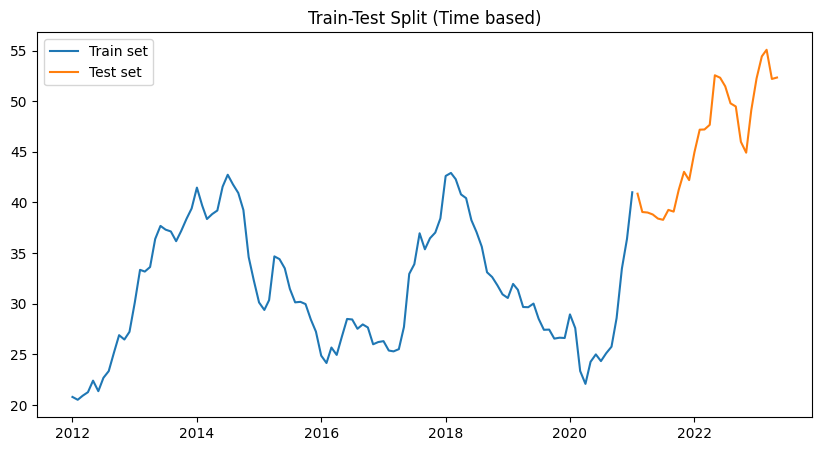

In [47]:
plt.figure(figsize=(10,5))
plt.plot(train_set, label='Train set')
plt.plot(test_set, label='Test set')
plt.legend()
plt.title('Train-Test Split (Time based)')
plt.show()

In [48]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_set,
    order=(1,1,0),
    seasonal_order=(1,1,0,12)
)

result = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [49]:
res_forecast = result.forecast(steps=(len(test_set)))

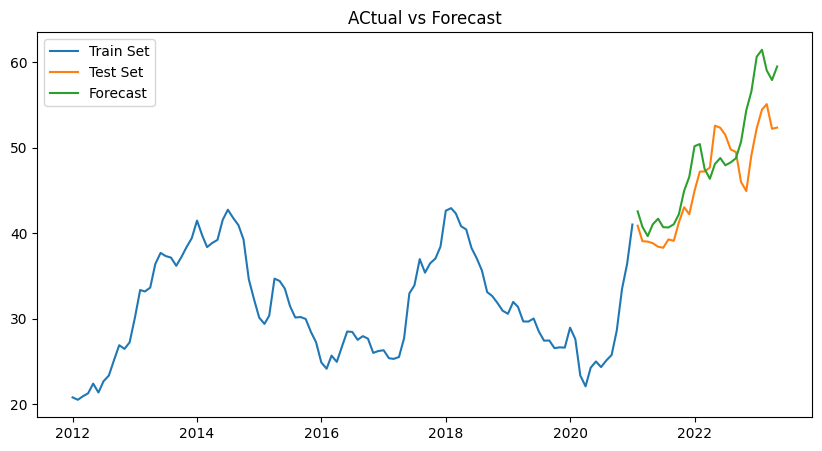

In [58]:
plt.figure(figsize=(10,5))
plt.plot(train_set, label='Train Set')
plt.plot(test_set, label='Test Set')
plt.plot(res_forecast, label='Forecast')
plt.legend()
plt.title('ACtual vs Forecast')
plt.show()

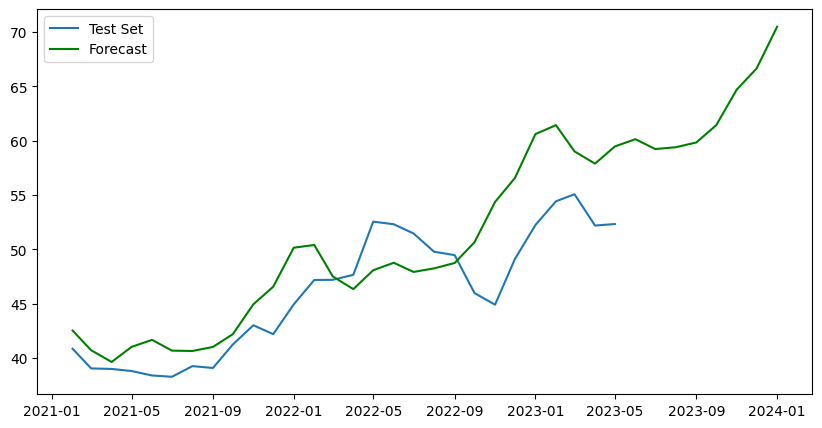

In [60]:
forecast = result.get_forecast(steps = 36)

plt.figure(figsize=(10,5))
plt.plot(test_set, label='Test Set')
plt.plot(forecast.predicted_mean, label='Forecast', color='green')
plt.legend()
plt.show()